In [1]:
import pandas as pd 
import numpy as np

In [2]:
file_path = "../data/dados_bitcoin_gdelt_limpos.csv"
df = pd.read_csv(file_path)

In [3]:
display(df)

,EventTimestamp,Source,URL,SentimentScore,Temas,Organizacoes
0,2020-07-21 17:15:00+00:00,reuters.com,https://af.reuters.com/article/worldNews/idAFK...,-5.590062,"WB_678_DIGITAL_GOVERNMENT,2652;WB_670_ICT_SECU...","Chinese Embassy,552;National Security John Dem..."
1,2021-05-19 04:30:00+00:00,reuters.com,https://cn.reuters.com/article/china-virtual-c...,-2.649007,"WB_2048_COMPENSATION_CAREERS_AND_INCENTIVES,79...",Association China Banking The Association Chin...
2,2020-12-18 09:45:00+00:00,reuters.com,https://cn.reuters.com/article/global-markets-...,1.504788,"CRISISLEX_CRISISLEXREC,976;EPU_POLICY_CONGRESS...","Swiss National Bank,3111;Federal Reserve,454;F..."
3,2021-05-13 07:30:00+00:00,reuters.com,https://cn.reuters.com/article/huobi-0513-thur...,0.743494,"WB_336_NON_BANK_FINANCIAL_INSTITUTIONS,1231;WB...","Group Operations,725"
4,2021-08-07 10:45:00+00:00,cointelegraph.com,https://cointelegraph.com/authors/laurent-descout,-4.347826,"ECON_BITCOIN,71;",NaN
...,...,...,...,...,...,...
48644,2021-07-16 04:15:00+00:00,reuters.com,https://www.reuters.com/technology/pakistan-mo...,0.000000,"IDEOLOGY,4519;SOC_POINTSOFINTEREST_UNIVERSITIE...","Thomson Reuters Trust Principles,4519;Financia..."
48645,2021-04-27 11:00:00+00:00,reuters.com,https://www.reuters.com/world/asia-pacific/dol...,-0.566038,"IDEOLOGY,3062;GENERAL_HEALTH,491;HEALTH_VACCIN...","Thomson Reuters Trust Principles,3062;Commonwe..."
48646,2021-07-27 03:00:00+00:00,reuters.com,https://www.reuters.com/world/china/global-mar...,-0.612245,"IDEOLOGY,2786;ECON_WORLDCURRENCIES_DOLLAR,1956...","Thomson Reuters Trust Principles,2786;Microsof..."
48647,2021-04-14 18:45:00+00:00,reuters.com,https://www.reuters.com/www.reuters.com/articl...,-1.457195,"IDEOLOGY,3219;TAX_FNCACT_DIRECTOR,2447;TAX_FNC...","Coinbase Global Inc,54;Coinbase Global Inc,238..."


In [4]:
temas_limpos = df['Temas'].dropna()

    # 1. Quebra a string, remove duplicatas da mesma linha (usando set) e transforma de volta em lista
tags_unicas_por_noticia = temas_limpos.apply(
        lambda x: list(set([tag.strip() for tag in x.replace(',', ';').split(';') if tag.strip() != '']))
    )

    # 2. Agora sim fazemos o explode (cada tag aparecerá no máximo 1 vez por notícia)
todas_as_tags_sem_duplicatas = tags_unicas_por_noticia.explode()

print("\nAs 40 tags presentes no maior número de NOTÍCIAS:")
top_tags = todas_as_tags_sem_duplicatas.value_counts().head(40)

# Extrai APENAS os nomes das organizações transformando o índice em uma lista
nome_das_tags = top_tags.index.tolist()

print("\nLista apenas com os nomes das 40 tags mais frequentes:")
print(nome_das_tags)


As 40 tags presentes no maior número de NOTÍCIAS:

Lista apenas com os nomes das 40 tags mais frequentes:
['ECON_BITCOIN', 'WB_698_TRADE', 'TAX_ECON_PRICE', 'USPEC_POLICY1', 'EPU_ECONOMY_HISTORIC', 'WB_696_PUBLIC_SECTOR_MANAGEMENT', 'UNGP_FORESTS_RIVERS_OCEANS', 'WB_133_INFORMATION_AND_COMMUNICATION_TECHNOLOGIES', 'USPEC_POLITICS_GENERAL1', 'CRISISLEX_CRISISLEXREC', 'WB_678_DIGITAL_GOVERNMENT', 'WB_1920_FINANCIAL_SECTOR_DEVELOPMENT', 'WB_1104_MACROECONOMIC_VULNERABILITY_AND_DEBT', 'ECON_STOCKMARKET', 'EPU_CATS_MONETARY_POLICY', 'GENERAL_GOVERNMENT', 'EPU_POLICY_POLICY', 'LEADER', 'EPU_ECONOMY', 'MEDIA_SOCIAL', 'EPU_CATS_REGULATION', 'TAX_FNCACT_CEO', 'TAX_FNCACT_TRADERS', 'EPU_POLICY_GOVERNMENT', 'IDEOLOGY', 'CRISISLEX_C07_SAFETY', 'TAX_FNCACT_PRESIDENT', 'EPU_POLICY_REGULATORY', 'ECON_WORLDCURRENCIES_DOLLAR', 'WB_507_ENERGY_AND_EXTRACTIVES', 'WB_694_BROADCAST_AND_MEDIA', 'WB_840_JUSTICE', 'TAX_FNCACT_CHIEF', 'WB_318_FINANCIAL_ARCHITECTURE_AND_BANKING', 'WB_831_GOVERNANCE', 'TAX_FNCAC

In [5]:
organizacoes = df['Organizacoes'].dropna()
    
    # 1. Quebra a string, remove duplicatas da mesma linha (usando set) e transforma de volta em lista
tags_unicas_por_noticia = organizacoes.apply(
            lambda x: list(set([tag.strip() for tag in x.replace(',', ';').split(';') if tag.strip() != '']))
        )
    
    # 2. Agora sim fazemos o explode (cada tag aparecerá no máximo 1 vez por notícia)
todas_as_tags_sem_duplicatas = tags_unicas_por_noticia.explode()
    
print("\nAs 40 organizacoes presentes no maior número de NOTÍCIAS:")
top_40_organizacoes = todas_as_tags_sem_duplicatas.value_counts().head(40)

# Extrai APENAS os nomes das organizações transformando o índice em uma lista
nomes_das_organizacoes = top_40_organizacoes.index.tolist()

print("\nLista apenas com os nomes das 40 organizações mais frequentes:")
print(nomes_das_organizacoes)


As 40 organizacoes presentes no maior número de NOTÍCIAS:

Lista apenas com os nomes das 40 organizações mais frequentes:
['Reuters', 'United States', 'Thomson Reuters Trust Principles', 'Exchange Commission', 'Twitter', 'Federal Reserve', 'Nasdaq', 'Thomson Reuters', 'Blackrock', 'Digital Currency Group', 'Bloomberg', 'European Union', '10', 'Google', 'European Central Bank', 'Facebook', 'Market Committee', 'White House', 'Youtube', 'Commodity Futures Trading Commission', 'Tesla Inc', 'Sterling', 'Grayscale Bitcoin Trust', '39', '8', 'Goldman Sachs', 'Microsoft', '49', '52', 'Visa', 'Mastercard', 'New York Times', 'Alameda Research', 'Central Bank', 'York Stock Exchange', '245', 'Bitcoin Trust', 'Lightning Network', 'Nvidia', '232']


In [6]:
ORG_CLUSTERS = {                                                                                                                                                                         
        'org_central_banks': ['Federal Reserve', 'European Central Bank', 'Central Bank', 'Market Committee'],                                                                               
        'org_regulators_gov': ['Exchange Commission', 'Commodity Futures Trading Commission', 'White House', 'European Union', 'United States'],                                             
        'org_tradfi_institutions': ['Blackrock', 'Goldman Sachs', 'Sterling'],                                                                                                               
        'org_exchanges_payments': ['Nasdaq', 'York Stock Exchange', 'Visa', 'Mastercard'],                                                                                                   
        'org_crypto_ecosystem': ['Grayscale Bitcoin Trust', 'Bitcoin Trust', 'Digital Currency Group', 'Alameda Research', 'Lightning Network'],                                             
        'org_tech_giants': ['Tesla Inc', 'Nvidia', 'Microsoft', 'Google', 'Facebook'],                                                                                                       
        'org_media_social': ['Reuters', 'Thomson Reuters', 'Thomson Reuters Trust Principles', 'Bloomberg', 'New York Times', 'Twitter', 'Youtube']                                          
    }                                                                                                                                                                                        
                                                                                                                                                                                             
TAG_CLUSTERS = {                                                                                                                                                                         
        'tag_macro_monetary': ['EPU_CATS_MONETARY_POLICY', 'ECON_WORLDCURRENCIES_DOLLAR', 'WB_1045_TREASURY', 'WB_713_PUBLIC_FINANCE', 'WB_1104_MACROECONOMIC_VULNERABILITY_AND_DEBT',       
  'TAX_ECON_PRICE', 'EPU_ECONOMY', 'EPU_ECONOMY_HISTORIC', 'WB_698_TRADE'],                                                                                                                  
        'tag_regulation_law': ['EPU_CATS_REGULATION', 'EPU_POLICY_REGULATORY', 'LEGISLATION', 'WB_840_JUSTICE', 'WB_831_GOVERNANCE', 'EPU_POLICY_POLICY'],
        'tag_gov_politics': ['GENERAL_GOVERNMENT', 'EPU_POLICY_GOVERNMENT', 'USPEC_POLICY1', 'USPEC_POLITICS_GENERAL1', 'WB_678_DIGITAL_GOVERNMENT', 'WB_696_PUBLIC_SECTOR_MANAGEMENT'],     
        'tag_markets_crypto': ['ECON_BITCOIN', 'ECON_STOCKMARKET', 'WB_318_FINANCIAL_ARCHITECTURE_AND_BANKING', 'WB_1920_FINANCIAL_SECTOR_DEVELOPMENT'],
        'tag_tech_energy': ['WB_133_INFORMATION_AND_COMMUNICATION_TECHNOLOGIES', 'WB_507_ENERGY_AND_EXTRACTIVES', 'UNGP_FORESTS_RIVERS_OCEANS'],
        'tag_sentiment_fear': ['MEDIA_SOCIAL', 'WB_694_BROADCAST_AND_MEDIA', 'EPU_CATS_MIGRATION_FEAR_FEAR', 'CRISISLEX_CRISISLEXREC', 'CRISISLEX_C07_SAFETY', 'IDEOLOGY'],
        'tag_actor_roles': ['TAX_FNCACT_CEO', 'TAX_FNCACT_TRADERS', 'TAX_FNCACT_PRESIDENT', 'TAX_FNCACT_CHIEF', 'TAX_FNCACT_ANALYST', 'LEADER']
    }

In [7]:
def clean_gdelt_entities(raw_str):
        if pd.isna(raw_str):
            return set()
        cleaned = set()
        for item in str(raw_str).split(';'):
            name = item.rsplit(',', 1)[0].strip()
            if name and not name.isdigit():
                cleaned.add(name)
        return cleaned
  
def build_7x7_features(df):
        parsed_orgs = df['Organizacoes'].apply(clean_gdelt_entities)
        parsed_tags = df['Temas'].apply(clean_gdelt_entities)
        
        # 7 Org Columns
        for col_name, keywords in ORG_CLUSTERS.items():
            kw_set = set(keywords)
            df[col_name] = parsed_orgs.apply(lambda orgs: len(orgs.intersection(kw_set)))
            
        # 7 Tag Columns
        for col_name, keywords in TAG_CLUSTERS.items():
            kw_set = set(keywords)
            df[col_name] = parsed_tags.apply(lambda tags: len(tags.intersection(kw_set)))
            
        return df

In [8]:
df = build_7x7_features(df)

In [9]:
display(df.head())

,EventTimestamp,Source,URL,SentimentScore,Temas,Organizacoes,org_central_banks,org_regulators_gov,org_tradfi_institutions,org_exchanges_payments,org_crypto_ecosystem,org_tech_giants,org_media_social,tag_macro_monetary,tag_regulation_law,tag_gov_politics,tag_markets_crypto,tag_tech_energy,tag_sentiment_fear,tag_actor_roles
0,2020-07-21 17:15:00+00:00,reuters.com,https://af.reuters.com/article/worldNews/idAFK...,-5.590062,"WB_678_DIGITAL_GOVERNMENT,2652;WB_670_ICT_SECU...","Chinese Embassy,552;National Security John Dem...",0,1,0,0,0,0,0,0,2,4,1,2,2,1
1,2021-05-19 04:30:00+00:00,reuters.com,https://cn.reuters.com/article/china-virtual-c...,-2.649007,"WB_2048_COMPENSATION_CAREERS_AND_INCENTIVES,79...",Association China Banking The Association Chin...,0,0,0,0,0,0,0,4,2,2,2,0,2,0
2,2020-12-18 09:45:00+00:00,reuters.com,https://cn.reuters.com/article/global-markets-...,1.504788,"CRISISLEX_CRISISLEXREC,976;EPU_POLICY_CONGRESS...","Swiss National Bank,3111;Federal Reserve,454;F...",1,1,0,1,0,0,1,9,1,5,2,1,1,3
3,2021-05-13 07:30:00+00:00,reuters.com,https://cn.reuters.com/article/huobi-0513-thur...,0.743494,"WB_336_NON_BANK_FINANCIAL_INSTITUTIONS,1231;WB...","Group Operations,725",0,0,0,0,0,0,0,3,0,0,2,0,0,1
4,2021-08-07 10:45:00+00:00,cointelegraph.com,https://cointelegraph.com/authors/laurent-descout,-4.347826,"ECON_BITCOIN,71;",NaN,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48649 entries, 0 to 48648
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EventTimestamp           48649 non-null  str    
 1   Source                   48649 non-null  str    
 2   URL                      48649 non-null  str    
 3   SentimentScore           48649 non-null  float64
 4   Temas                    48485 non-null  str    
 5   Organizacoes             37864 non-null  str    
 6   org_central_banks        48649 non-null  int64  
 7   org_regulators_gov       48649 non-null  int64  
 8   org_tradfi_institutions  48649 non-null  int64  
 9   org_exchanges_payments   48649 non-null  int64  
 10  org_crypto_ecosystem     48649 non-null  int64  
 11  org_tech_giants          48649 non-null  int64  
 12  org_media_social         48649 non-null  int64  
 13  tag_macro_monetary       48649 non-null  int64  
 14  tag_regulation_law       48649 no

In [13]:
print(df['SentimentScore'].mean())

-0.7136493899649313


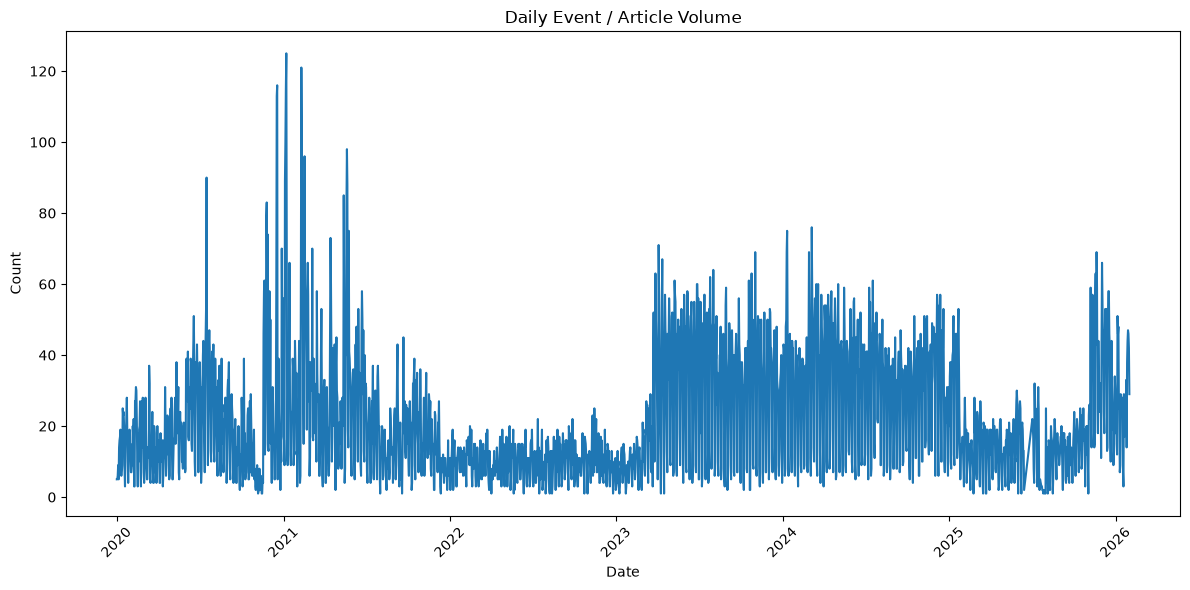

Average Sentiment by Tag:
tag_macro_monetary: -0.7530
tag_regulation_law: -0.5893
tag_gov_politics: -0.7585
tag_markets_crypto: -0.6208
tag_tech_energy: -0.5248
tag_sentiment_fear: -0.6146


In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Assuming your dataframe is named 'df'
# 1. Convert timestamp to datetime
df["EventTimestamp"] = pd.to_datetime(df["EventTimestamp"])
df["Date"] = df["EventTimestamp"].dt.date

# 2. Daily Sentiment and Volume Trend
daily_stats = (
    df.groupby("Date")
    .agg(
        Article_Count=("SentimentScore", "count"),
        Mean_Sentiment=("SentimentScore", "mean"),
    )
    .reset_index()
)

# 3. Quick visualization of volume over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_stats, x="Date", y="Article_Count")
plt.title("Daily Event / Article Volume")
plt.xlabel("Date")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Compare Sentiment across Tag Categories
tag_columns = [
    "tag_macro_monetary",
    "tag_regulation_law",
    "tag_gov_politics",
    "tag_markets_crypto",
    "tag_tech_energy",
    "tag_sentiment_fear",
]

sentiment_by_tag = {}
for tag in tag_columns:
  sentiment_by_tag[tag] = df[df[tag] == 1]["SentimentScore"].mean()

print("Average Sentiment by Tag:")
for tag, score in sentiment_by_tag.items():
  print(f"{tag}: {score:.4f}")